Dimensiones del conjunto de entrenamiento: (891, 12)
Dimensiones del conjunto de prueba: (418, 11)

Análisis de valores faltantes:
             Valores Faltantes  Porcentaje
PassengerId                  0    0.000000
Survived                     0    0.000000
Pclass                       0    0.000000
Name                         0    0.000000
Sex                          0    0.000000
Age                        177   19.865320
SibSp                        0    0.000000
Parch                        0    0.000000
Ticket                       0    0.000000
Fare                         0    0.000000
Cabin                      687   77.104377
Embarked                     2    0.224467


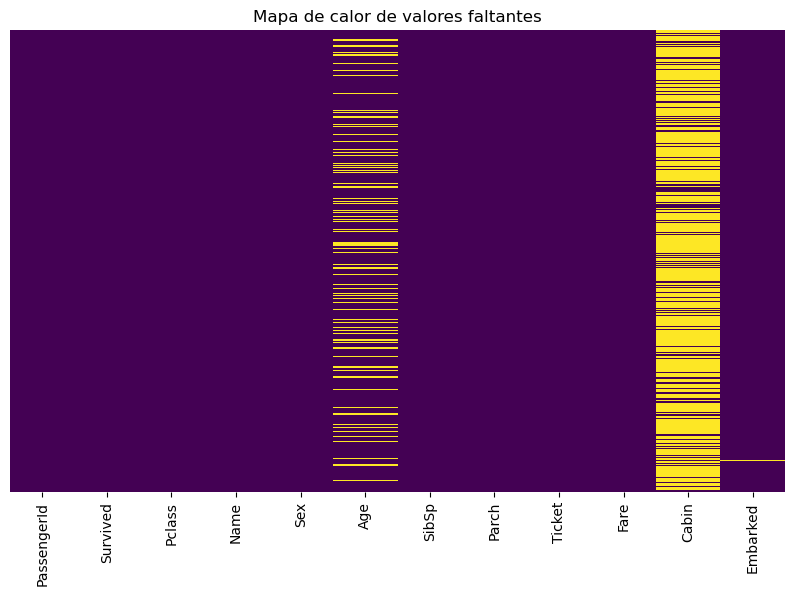

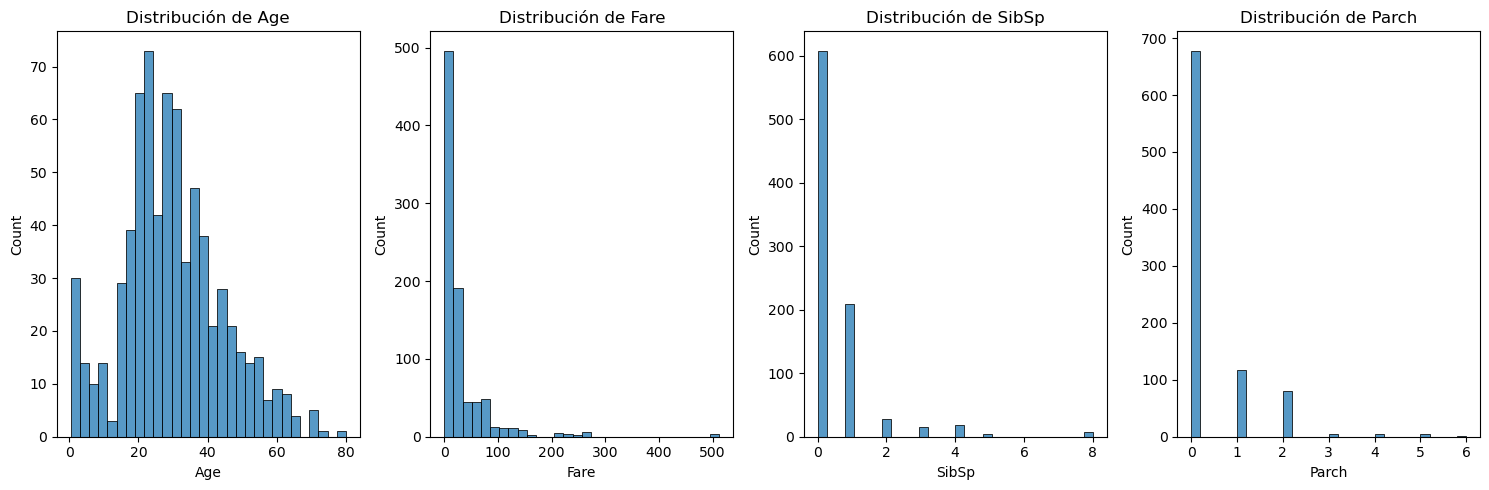

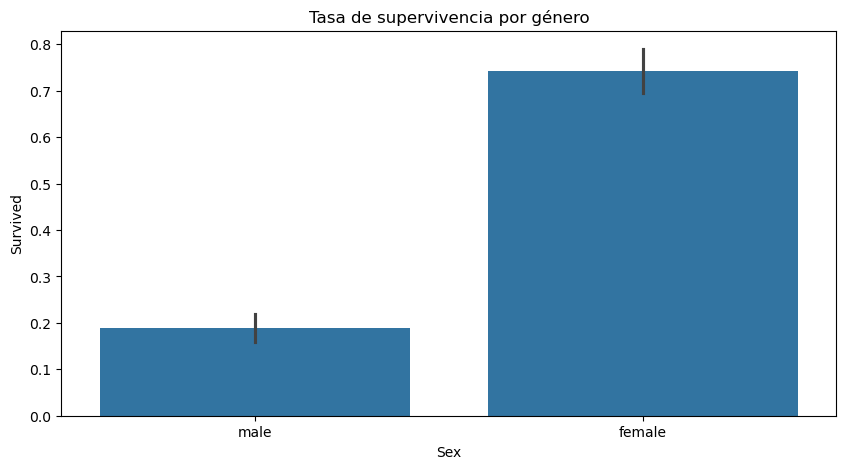

C:\Users\Ivan\AppData\Local\Temp\ipykernel_26120\2074287254.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)



Valores faltantes después del preprocesamiento:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


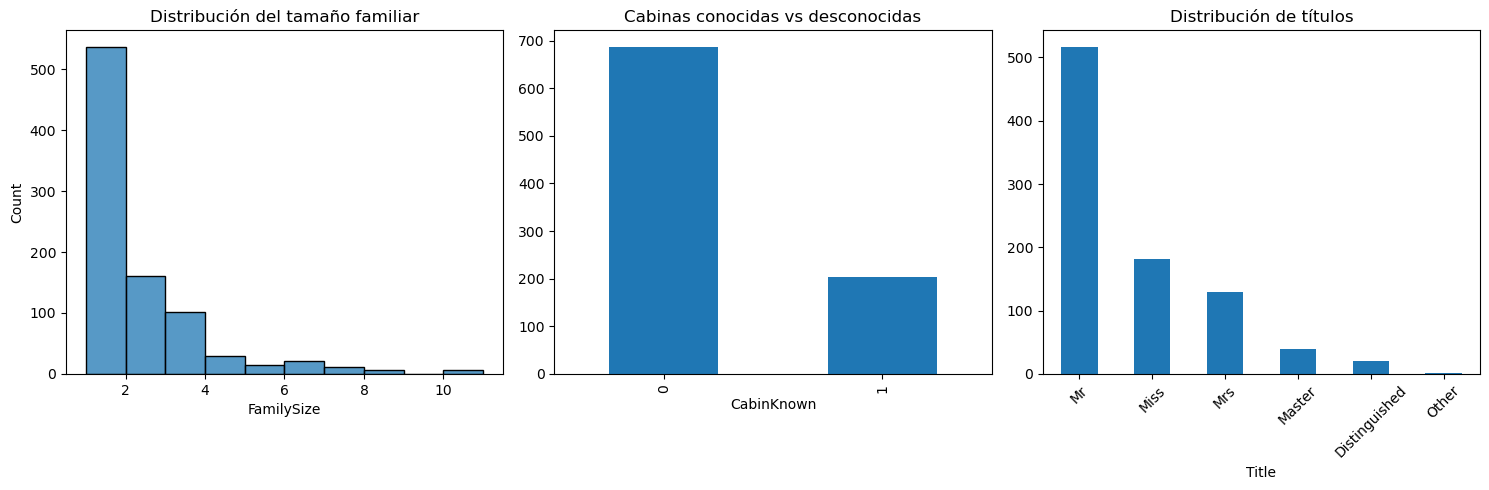

c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 1200x600 with 0 Axes>

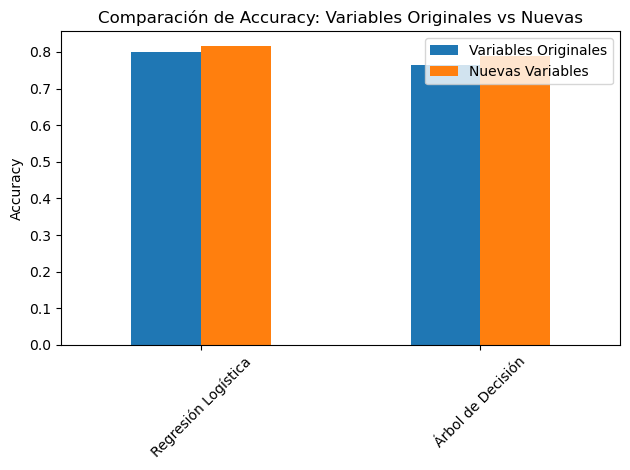


Resultados detallados:

Modelo: Regresión Logística
Variables Originales - Accuracy: 0.799, F1: 0.753
Nuevas Variables     - Accuracy: 0.816, F1: 0.769

Modelo: Árbol de Decisión
Variables Originales - Accuracy: 0.765, F1: 0.724
Nuevas Variables     - Accuracy: 0.788, F1: 0.753


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import re

# 1. Carga de Datos
# Leemos los datasets de train y test
train_df = pd.read_csv('../../../data/titanic/train.csv')
test_df = pd.read_csv('../../../data/titanic/test.csv')

print("Dimensiones del conjunto de entrenamiento:", train_df.shape)
print("Dimensiones del conjunto de prueba:", test_df.shape)

# Mostrar las primeras filas
train_df.head()

# Análisis de valores faltantes
missing_values = train_df.isnull().sum()
missing_percentages = (missing_values / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentaje': missing_percentages
})
print("\nAnálisis de valores faltantes:")
print(missing_df)

# Visualización de valores faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores faltantes')
plt.show()

# 2. Exploración inicial de variables numéricas
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 4, i)
    sns.histplot(data=train_df, x=col, bins=30)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# Análisis de supervivencia por género
plt.figure(figsize=(10, 5))
sns.barplot(data=train_df, x='Sex', y='Survived')
plt.title('Tasa de supervivencia por género')
plt.show()

# 3. Preprocesamiento de datos
def preprocesar_datos(df):
    df_processed = df.copy()
    
    # Imputar edad con la mediana
    age_imputer = SimpleImputer(strategy='median')
    df_processed['Age'] = age_imputer.fit_transform(df_processed[['Age']])
    
    # Imputar tarifa con la mediana
    fare_imputer = SimpleImputer(strategy='median')
    df_processed['Fare'] = fare_imputer.fit_transform(df_processed[['Fare']])
    
    # Rellenar Embarked con el valor más común
    df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)
    
    return df_processed

train_processed = preprocesar_datos(train_df)

# Verificar que no hay valores faltantes después del preprocesamiento
print("\nValores faltantes después del preprocesamiento:")
print(train_processed.isnull().sum())

# 4. Creación de nuevas características
def crear_nuevas_caracteristicas(df):
    df_features = df.copy()
    
    # Tamaño de la familia
    df_features['FamilySize'] = df_features['SibSp'] + df_features['Parch'] + 1
    
    # Cabina desconocida
    df_features['CabinKnown'] = df_features['Cabin'].notna().astype(int)
    
    # Categoría de tarifa
    df_features['FareCategory'] = pd.qcut(df_features['Fare'], 
                                        q=4, 
                                        labels=['Económico', 'Moderado', 'Costoso', 'Premium'])
    
    # Título del pasajero
    def extract_title(name):
        title_search = re.search(' ([A-Za-z]+)\.', name)
        if title_search:
            title = title_search.group(1)
            if title in ['Mr', 'Mrs', 'Miss', 'Master']:
                return title
            elif title in ['Don', 'Rev', 'Dr', 'Major', 'Sir', 'Col', 'Capt']:
                return 'Distinguished'
            elif title in ['Mme', 'Ms', 'Lady', 'Dona', 'Mlle']:
                return 'Mrs'
            else:
                return 'Other'
        return 'Other'
    
    df_features['Title'] = df_features['Name'].apply(extract_title)
    
    return df_features

train_features = crear_nuevas_caracteristicas(train_processed)

# Visualizar las nuevas características
plt.figure(figsize=(15, 5))

# Distribución de FamilySize
plt.subplot(131)
sns.histplot(data=train_features, x='FamilySize', bins=10)
plt.title('Distribución del tamaño familiar')

# Proporción de CabinKnown
plt.subplot(132)
train_features['CabinKnown'].value_counts().plot(kind='bar')
plt.title('Cabinas conocidas vs desconocidas')

# Distribución de títulos
plt.subplot(133)
train_features['Title'].value_counts().plot(kind='bar')
plt.title('Distribución de títulos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Preparación para el modelado
le = LabelEncoder()

# Variables originales
X_orig = pd.DataFrame({
    'Pclass': train_processed['Pclass'],
    'Sex': le.fit_transform(train_processed['Sex']),
    'Age': train_processed['Age'],
    'Fare': train_processed['Fare'],
    'Embarked': le.fit_transform(train_processed['Embarked'])
})

# Nuevas variables
X_new = pd.DataFrame({
    'Pclass': train_features['Pclass'],
    'Sex': le.fit_transform(train_features['Sex']),
    'Age': train_features['Age'],
    'Fare': train_features['Fare'],
    'Embarked': le.fit_transform(train_features['Embarked']),
    'FamilySize': train_features['FamilySize'],
    'CabinKnown': train_features['CabinKnown'],
    'FareCategory': le.fit_transform(train_features['FareCategory']),
    'Title': le.fit_transform(train_features['Title'])
})

y = train_df['Survived']

# 6. Evaluación de modelos
def evaluar_modelos(X_orig, X_new, y):
    # Dividir datos
    X_orig_train, X_orig_test, y_train, y_test = train_test_split(
        X_orig, y, test_size=0.2, random_state=42
    )
    X_new_train, X_new_test, _, _ = train_test_split(
        X_new, y, test_size=0.2, random_state=42
    )
    
    models = {
        'Regresión Logística': LogisticRegression(random_state=42),
        'Árbol de Decisión': DecisionTreeClassifier(random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Modelo con características originales
        model.fit(X_orig_train, y_train)
        y_pred_orig = model.predict(X_orig_test)
        
        # Modelo con nuevas características
        model.fit(X_new_train, y_train)
        y_pred_new = model.predict(X_new_test)
        
        results[name] = {
            'Original_Accuracy': accuracy_score(y_test, y_pred_orig),
            'Original_F1': f1_score(y_test, y_pred_orig),
            'New_Accuracy': accuracy_score(y_test, y_pred_new),
            'New_F1': f1_score(y_test, y_pred_new)
        }
    
    return results

# Ejecutar evaluación
results = evaluar_modelos(X_orig, X_new, y)

# Visualizar resultados
results_df = pd.DataFrame(results).T
plt.figure(figsize=(12, 6))
results_df[['Original_Accuracy', 'New_Accuracy']].plot(kind='bar')
plt.title('Comparación de Accuracy: Variables Originales vs Nuevas')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(['Variables Originales', 'Nuevas Variables'])
plt.tight_layout()
plt.show()

# Mostrar resultados detallados
print("\nResultados detallados:")
for model_name, metrics in results.items():
    print(f"\nModelo: {model_name}")
    print(f"Variables Originales - Accuracy: {metrics['Original_Accuracy']:.3f}, F1: {metrics['Original_F1']:.3f}")
    print(f"Nuevas Variables     - Accuracy: {metrics['New_Accuracy']:.3f}, F1: {metrics['New_F1']:.3f}")